# CSL / PHOENIX / Neural Sign Actors Exploration & Statistics

This notebook explores new SOKE data folders:

- `DATA/SOKE_DATA/CSL-Daily-Fittings`
- `DATA/SOKE_DATA/phoenix_poses`
- `DATA/SOKE_DATA/Neural-Sign-Actors`

It summarizes split sizes, clip/frame counts, pose-file schemas, sample records, and writes reproducible CSV/plot artifacts under `new_data/01_csl_phoenix_neural_sign_actors_exploration_and_stats/`.



In [1]:

from pathlib import Path
import gzip
import importlib.util
import json
import os
import pickle
import random
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# WSL CUDA reliability guard: keep CUDA stubs visible before importing torch.
if Path('/usr/lib/wsl/lib').exists():
    _wsl_cuda_lib = '/usr/lib/wsl/lib'
    _ld = os.environ.get('LD_LIBRARY_PATH', '')
    _parts = [p for p in _ld.split(':') if p]
    if _wsl_cuda_lib not in _parts:
        os.environ['LD_LIBRARY_PATH'] = f"{_wsl_cuda_lib}:{_ld}" if _ld else _wsl_cuda_lib
        print(f'Prepended WSL CUDA loader path: {_wsl_cuda_lib}')

TORCH_AVAILABLE = importlib.util.find_spec('torch') is not None
if TORCH_AVAILABLE:
    import torch
    print(f'Torch available: {torch.__version__}')
    print(f'CUDA available: {torch.cuda.is_available()}')
    if torch.cuda.is_available():
        print(f'CUDA device: {torch.cuda.get_device_name(torch.cuda.current_device())}')
else:
    print('Torch is not installed in this kernel. Torch is only needed for .pt stats or optional rendering.')

plt.style.use('seaborn-v0_8-whitegrid')
RNG_SEED = int(os.environ.get('NEW_DATA_RNG_SEED', '42'))
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)


Torch available: 2.10.0+cu128
CUDA available: True
CUDA device: NVIDIA GeForce RTX 4090


In [2]:

def find_project_root() -> Path:
    cur = Path.cwd().resolve()
    for p in [cur, *cur.parents]:
        if (p / 'DATA').exists() and (p / 'new_data').exists():
            return p
    return Path.cwd().resolve()

ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
DATA_DIR = ROOT / 'DATA'
SOKE_DATA = DATA_DIR / 'SOKE_DATA'

CSL_ROOT = SOKE_DATA / 'CSL-Daily-Fittings'
CSL_POSE_ROOT = CSL_ROOT / 'csl-daily_pose' / 'csl-daily_pose'
PHOENIX_ROOT = SOKE_DATA / 'phoenix_poses'
NSA_ROOT = SOKE_DATA / 'Neural-Sign-Actors'

NOTEBOOK_NAME = '01_csl_phoenix_neural_sign_actors_exploration_and_stats'
ARTIFACT_DIR = ROOT / 'new_data' / NOTEBOOK_NAME
PLOT_DIR = ARTIFACT_DIR / 'plots'
for d in [ARTIFACT_DIR, PLOT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

MAX_CLIPS_PER_SPLIT_TEXT = os.environ.get('NEW_DATA_MAX_CLIPS_PER_SPLIT', '').strip()
MAX_CLIPS_PER_SPLIT = int(MAX_CLIPS_PER_SPLIT_TEXT) if MAX_CLIPS_PER_SPLIT_TEXT else None
RUN_RENDER = os.environ.get('NEW_DATA_RUN_RENDER', '0') == '1'
SAMPLE_SIZE = int(os.environ.get('NEW_DATA_SAMPLE_SIZE', '10'))

print('ROOT:', ROOT)
print('SOKE_DATA:', SOKE_DATA, '| exists:', SOKE_DATA.exists())
for label, path in [('CSL_ROOT', CSL_ROOT), ('CSL_POSE_ROOT', CSL_POSE_ROOT), ('PHOENIX_ROOT', PHOENIX_ROOT), ('NSA_ROOT', NSA_ROOT)]:
    print(f'{label}: {path} | exists={path.exists()}')
print('ARTIFACT_DIR:', ARTIFACT_DIR)
print('MAX_CLIPS_PER_SPLIT:', MAX_CLIPS_PER_SPLIT)
print('RUN_RENDER:', RUN_RENDER)


ROOT: /home/cem/tez/exp
SOKE_DATA: /home/cem/tez/exp/DATA/SOKE_DATA | exists: True
CSL_ROOT: /home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fittings | exists=True
CSL_POSE_ROOT: /home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fittings/csl-daily_pose/csl-daily_pose | exists=True
PHOENIX_ROOT: /home/cem/tez/exp/DATA/SOKE_DATA/phoenix_poses | exists=True
NSA_ROOT: /home/cem/tez/exp/DATA/SOKE_DATA/Neural-Sign-Actors | exists=True
ARTIFACT_DIR: /home/cem/tez/exp/new_data/01_csl_phoenix_neural_sign_actors_exploration_and_stats
MAX_CLIPS_PER_SPLIT: None
RUN_RENDER: False


In [3]:

def _to_numpy(x):
    if TORCH_AVAILABLE:
        import torch
        if isinstance(x, torch.Tensor):
            return x.detach().cpu().numpy()
    if isinstance(x, np.ndarray):
        return x
    return x


def load_pickle_or_torch(path: Path):
    path = Path(path)
    if TORCH_AVAILABLE:
        try:
            return torch.load(path, map_location='cpu', weights_only=False)
        except Exception:
            pass
    with path.open('rb') as f:
        return pickle.load(f)


def load_gzip_pickle(path: Path):
    with gzip.open(path, 'rb') as f:
        return pickle.load(f)


def count_matching_files(dir_path: Path, suffix: str = '.pkl') -> int:
    try:
        with os.scandir(dir_path) as it:
            return sum(1 for e in it if e.is_file() and e.name.endswith(suffix))
    except FileNotFoundError:
        return 0


def list_clip_dirs(root: Path) -> list[Path]:
    if not root.exists():
        return []
    return sorted([p for p in root.iterdir() if p.is_dir()])


def maybe_limit_dirs(dirs: list[Path], split: str) -> list[Path]:
    if MAX_CLIPS_PER_SPLIT is None or len(dirs) <= MAX_CLIPS_PER_SPLIT:
        return dirs
    rng = random.Random(RNG_SEED + abs(hash(split)) % 100000)
    return sorted(rng.sample(dirs, MAX_CLIPS_PER_SPLIT))


def safe_len(value):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return 0
    if isinstance(value, (list, tuple, set)):
        return len(value)
    return len(str(value).split())


def describe_frame_schema(path: Path) -> dict:
    obj = load_pickle_or_torch(path)
    row = {'path': str(path), 'type': type(obj).__name__}
    if isinstance(obj, dict):
        row['keys'] = ', '.join(map(str, obj.keys()))
        for k, v in obj.items():
            v = _to_numpy(v)
            shape = tuple(np.shape(v)) if hasattr(v, 'shape') or isinstance(v, (list, tuple)) else None
            dtype = str(getattr(v, 'dtype', '')) if hasattr(v, 'dtype') else ''
            row[f'{k}_shape'] = shape
            row[f'{k}_dtype'] = dtype
    else:
        row['repr'] = repr(obj)[:200]
        row['shape'] = tuple(np.shape(obj)) if hasattr(obj, 'shape') else None
    return row


## CSL-Daily Fittings

The CSL split metadata files are gzip-compressed pickle lists. Each item has keys like `name`, `signer`, `gloss`, `text`, `sign`, and `num_frames`. Pose frames live under `csl-daily_pose/csl-daily_pose/<name>/*.pkl`.


In [4]:

def load_csl_split(split: str) -> pd.DataFrame:
    fp = CSL_ROOT / f'csl_clean.{split}'
    rows = load_gzip_pickle(fp)
    df = pd.DataFrame(rows)
    df['dataset'] = 'CSL-Daily-Fittings'
    df['split'] = 'val' if split == 'val' else split
    df['clip_id'] = df['name'].astype(str)
    df['pose_dir'] = df['clip_id'].map(lambda x: str(CSL_POSE_ROOT / x))
    df['pose_exists'] = df['pose_dir'].map(lambda x: Path(x).exists())
    df['metadata_num_frames'] = pd.to_numeric(df.get('num_frames'), errors='coerce')
    df['frame_pkls'] = [count_matching_files(Path(p), '.pkl') for p in df['pose_dir']]
    df['gloss_tokens'] = df.get('gloss', '').map(safe_len)
    df['text_tokens'] = df.get('text', '').map(safe_len)
    df['sign_tokens'] = df.get('sign', '').map(safe_len)
    df['scan_limited'] = False
    return df

csl_frames = []
for split in ['train', 'val', 'test']:
    df = load_csl_split(split)
    if MAX_CLIPS_PER_SPLIT is not None and len(df) > MAX_CLIPS_PER_SPLIT:
        df = df.sample(MAX_CLIPS_PER_SPLIT, random_state=RNG_SEED).sort_values('clip_id').reset_index(drop=True)
        df['scan_limited'] = True
    csl_frames.append(df)

csl_df = pd.concat(csl_frames, ignore_index=True)
print('CSL rows in this scan:', len(csl_df), '| limited:', bool(csl_df['scan_limited'].any()))
display(csl_df.head())

csl_split_stats = (
    csl_df.groupby(['dataset', 'split'])
    .agg(
        clips=('clip_id', 'nunique'),
        pose_dirs_found=('pose_exists', 'sum'),
        frame_pkls_sum=('frame_pkls', 'sum'),
        metadata_frames_sum=('metadata_num_frames', 'sum'),
        frame_pkls_mean=('frame_pkls', 'mean'),
        frame_pkls_median=('frame_pkls', 'median'),
        frame_pkls_p95=('frame_pkls', lambda s: float(np.percentile(s, 95))),
        frame_pkls_max=('frame_pkls', 'max'),
        signer_count=('signer', 'nunique'),
        gloss_tokens_mean=('gloss_tokens', 'mean'),
        text_tokens_mean=('text_tokens', 'mean'),
    )
    .reset_index()
)
display(csl_split_stats.round(3))


CSL rows in this scan: 20654 | limited: False


,name,signer,gloss,text,sign,num_frames,dataset,split,clip_id,pose_dir,pose_exists,metadata_num_frames,frame_pkls,gloss_tokens,text_tokens,sign_tokens,scan_limited
0,S000000_P0000_T00,0,你们 好,你们好！,[[tensor(0.)]],52,CSL-Daily-Fittings,train,S000000_P0000_T00,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,True,52,52,2,1,1,False
1,S000000_P0004_T00,4,你们 好,你们好！,[[tensor(0.)]],47,CSL-Daily-Fittings,train,S000000_P0004_T00,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,True,47,47,2,1,1,False
2,S000000_P0008_T00,8,你们 好,你们好！,[[tensor(0.)]],58,CSL-Daily-Fittings,train,S000000_P0008_T00,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,True,58,58,2,1,1,False
3,S000001_P0000_T00,0,对不起,对不起！,[[tensor(0.)]],37,CSL-Daily-Fittings,train,S000001_P0000_T00,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,True,37,37,1,1,1,False
4,S000001_P0004_T00,4,对不起,对不起！,[[tensor(0.)]],33,CSL-Daily-Fittings,train,S000001_P0004_T00,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,True,33,33,1,1,1,False


,dataset,split,clips,pose_dirs_found,frame_pkls_sum,metadata_frames_sum,frame_pkls_mean,frame_pkls_median,frame_pkls_p95,frame_pkls_max,signer_count,gloss_tokens_mean,text_tokens_mean
0,CSL-Daily-Fittings,test,1176,1176,149963,150248,127.520,122.0,217.5,340,10,7.655,1.0
1,CSL-Daily-Fittings,train,18401,18401,2179640,2185329,118.452,112.0,206.0,490,10,7.267,1.0
2,CSL-Daily-Fittings,val,1077,1077,131713,131931,122.296,117.0,207.2,339,10,7.589,1.0


## PHOENIX Pose Folders

PHOENIX is organized as `phoenix_poses/<split>/<clip_id>/imagesNNNN.pkl`. Each frame pickle contains SMPL-X pose keys plus 2D projected joints and hand/face boxes.


In [5]:

def scan_phoenix() -> pd.DataFrame:
    rows = []
    for split in ['train', 'dev', 'test']:
        split_root = PHOENIX_ROOT / split
        clip_dirs = maybe_limit_dirs(list_clip_dirs(split_root), f'phoenix_{split}')
        for clip_dir in clip_dirs:
            rows.append({
                'dataset': 'PHOENIX',
                'split': split,
                'clip_id': clip_dir.name,
                'pose_dir': str(clip_dir),
                'pose_exists': clip_dir.exists(),
                'frame_pkls': count_matching_files(clip_dir, '.pkl'),
                'scan_limited': MAX_CLIPS_PER_SPLIT is not None and len(list_clip_dirs(split_root)) > len(clip_dirs),
            })
    return pd.DataFrame(rows)

phoenix_df = scan_phoenix()
print('PHOENIX rows in this scan:', len(phoenix_df), '| limited:', bool(phoenix_df['scan_limited'].any()) if len(phoenix_df) else False)
display(phoenix_df.head())

phoenix_split_stats = (
    phoenix_df.groupby(['dataset', 'split'])
    .agg(
        clips=('clip_id', 'nunique'),
        frame_pkls_sum=('frame_pkls', 'sum'),
        frame_pkls_mean=('frame_pkls', 'mean'),
        frame_pkls_median=('frame_pkls', 'median'),
        frame_pkls_p95=('frame_pkls', lambda s: float(np.percentile(s, 95))),
        frame_pkls_max=('frame_pkls', 'max'),
    )
    .reset_index()
)
display(phoenix_split_stats.round(3))


PHOENIX rows in this scan: 8253 | limited: False


,dataset,split,clip_id,pose_dir,pose_exists,frame_pkls,scan_limited
0,PHOENIX,train,01April_2010_Thursday_heute-6694,/home/cem/tez/exp/DATA/SOKE_DATA/phoenix_poses...,True,53,False
1,PHOENIX,train,01April_2010_Thursday_heute-6695,/home/cem/tez/exp/DATA/SOKE_DATA/phoenix_poses...,True,90,False
2,PHOENIX,train,01April_2010_Thursday_heute-6696,/home/cem/tez/exp/DATA/SOKE_DATA/phoenix_poses...,True,28,False
3,PHOENIX,train,01April_2010_Thursday_heute-6700,/home/cem/tez/exp/DATA/SOKE_DATA/phoenix_poses...,True,164,False
4,PHOENIX,train,01April_2010_Thursday_heute-6701,/home/cem/tez/exp/DATA/SOKE_DATA/phoenix_poses...,True,57,False


,dataset,split,clips,frame_pkls_sum,frame_pkls_mean,frame_pkls_median,frame_pkls_p95,frame_pkls_max
0,PHOENIX,dev,519,54537,105.081,103.0,180.20,272
1,PHOENIX,test,642,63201,98.444,97.0,176.95,226
2,PHOENIX,train,7092,810045,114.220,109.0,205.00,473


## Neural Sign Actors Pose Folders

Neural Sign Actors is organized as `<split>_poses/poses/<clip_id>/<clip_id>_<frame>_3D.pkl`. Each frame pickle contains the same SMPL-X pose key family 

In [6]:

def scan_neural_sign_actors() -> pd.DataFrame:
    split_map = {'train': 'train_poses', 'val': 'val_poses', 'test': 'test_poses'}
    rows = []
    for split, folder in split_map.items():
        split_root = NSA_ROOT / folder / 'poses'
        all_dirs = list_clip_dirs(split_root)
        clip_dirs = maybe_limit_dirs(all_dirs, f'nsa_{split}')
        for clip_dir in clip_dirs:
            rows.append({
                'dataset': 'Neural-Sign-Actors',
                'split': split,
                'clip_id': clip_dir.name,
                'pose_dir': str(clip_dir),
                'pose_exists': clip_dir.exists(),
                'frame_pkls': count_matching_files(clip_dir, '.pkl'),
                'scan_limited': MAX_CLIPS_PER_SPLIT is not None and len(all_dirs) > len(clip_dirs),
            })
    return pd.DataFrame(rows)

nsa_df = scan_neural_sign_actors()
print('Neural Sign Actors rows in this scan:', len(nsa_df), '| limited:', bool(nsa_df['scan_limited'].any()) if len(nsa_df) else False)
display(nsa_df.head())

nsa_split_stats = (
    nsa_df.groupby(['dataset', 'split'])
    .agg(
        clips=('clip_id', 'nunique'),
        frame_pkls_sum=('frame_pkls', 'sum'),
        frame_pkls_mean=('frame_pkls', 'mean'),
        frame_pkls_median=('frame_pkls', 'median'),
        frame_pkls_p95=('frame_pkls', lambda s: float(np.percentile(s, 95))),
        frame_pkls_max=('frame_pkls', 'max'),
    )
    .reset_index()
)
display(nsa_split_stats.round(3))


Neural Sign Actors rows in this scan: 35007 | limited: False


,dataset,split,clip_id,pose_dir,pose_exists,frame_pkls,scan_limited
0,Neural-Sign-Actors,train,--7E2sU6zP4_10-5-rgb_front,/home/cem/tez/exp/DATA/SOKE_DATA/Neural-Sign-A...,True,365,False
1,Neural-Sign-Actors,train,--7E2sU6zP4_11-5-rgb_front,/home/cem/tez/exp/DATA/SOKE_DATA/Neural-Sign-A...,True,565,False
2,Neural-Sign-Actors,train,--7E2sU6zP4_12-5-rgb_front,/home/cem/tez/exp/DATA/SOKE_DATA/Neural-Sign-A...,True,349,False
3,Neural-Sign-Actors,train,--7E2sU6zP4_13-5-rgb_front,/home/cem/tez/exp/DATA/SOKE_DATA/Neural-Sign-A...,True,144,False
4,Neural-Sign-Actors,train,--7E2sU6zP4_5-5-rgb_front,/home/cem/tez/exp/DATA/SOKE_DATA/Neural-Sign-A...,True,212,False


,dataset,split,clips,frame_pkls_sum,frame_pkls_mean,frame_pkls_median,frame_pkls_p95,frame_pkls_max
0,Neural-Sign-Actors,test,2318,375380,161.941,127.0,422.45,1319
1,Neural-Sign-Actors,train,30965,5034216,162.578,126.0,425.00,2579
2,Neural-Sign-Actors,val,1724,273119,158.422,124.0,395.85,1761


## Combined Split Statistics

In [7]:

common_cols = ['dataset', 'split', 'clip_id', 'pose_dir', 'pose_exists', 'frame_pkls', 'scan_limited']
combined_df = pd.concat([
    csl_df[common_cols + ['metadata_num_frames', 'gloss_tokens', 'text_tokens', 'signer']].rename(columns={'metadata_num_frames': 'metadata_frames'}),
    phoenix_df[common_cols].assign(metadata_frames=np.nan, gloss_tokens=np.nan, text_tokens=np.nan, signer=np.nan),
    nsa_df[common_cols].assign(metadata_frames=np.nan, gloss_tokens=np.nan, text_tokens=np.nan, signer=np.nan),
], ignore_index=True)

combined_stats = (
    combined_df.groupby(['dataset', 'split'])
    .agg(
        clips=('clip_id', 'nunique'),
        pose_dirs_found=('pose_exists', 'sum'),
        frame_pkls_sum=('frame_pkls', 'sum'),
        frame_pkls_mean=('frame_pkls', 'mean'),
        frame_pkls_median=('frame_pkls', 'median'),
        frame_pkls_p95=('frame_pkls', lambda s: float(np.percentile(s, 95))),
        frame_pkls_max=('frame_pkls', 'max'),
        scan_limited=('scan_limited', 'max'),
    )
    .reset_index()
)

display(combined_stats.round(3))

summary_csv = ARTIFACT_DIR / 'combined_split_stats.csv'
clip_index_csv = ARTIFACT_DIR / 'combined_clip_index.csv'
combined_stats.to_csv(summary_csv, index=False)
combined_df.to_csv(clip_index_csv, index=False)
print('Wrote:', summary_csv)
print('Wrote:', clip_index_csv)


,dataset,split,clips,pose_dirs_found,frame_pkls_sum,frame_pkls_mean,frame_pkls_median,frame_pkls_p95,frame_pkls_max,scan_limited
0,CSL-Daily-Fittings,test,1176,1176,149963,127.520,122.0,217.50,340,False
1,CSL-Daily-Fittings,train,18401,18401,2179640,118.452,112.0,206.00,490,False
2,CSL-Daily-Fittings,val,1077,1077,131713,122.296,117.0,207.20,339,False
3,Neural-Sign-Actors,test,2318,2318,375380,161.941,127.0,422.45,1319,False
4,Neural-Sign-Actors,train,30965,30965,5034216,162.578,126.0,425.00,2579,False
5,Neural-Sign-Actors,val,1724,1724,273119,158.422,124.0,395.85,1761,False
6,PHOENIX,dev,519,519,54537,105.081,103.0,180.20,272,False
7,PHOENIX,test,642,642,63201,98.444,97.0,176.95,226,False
8,PHOENIX,train,7092,7092,810045,114.220,109.0,205.00,473,False


Wrote: /home/cem/tez/exp/new_data/01_csl_phoenix_neural_sign_actors_exploration_and_stats/combined_split_stats.csv
Wrote: /home/cem/tez/exp/new_data/01_csl_phoenix_neural_sign_actors_exploration_and_stats/combined_clip_index.csv


Wrote: /home/cem/tez/exp/new_data/01_csl_phoenix_neural_sign_actors_exploration_and_stats/plots/frame_count_stats.png


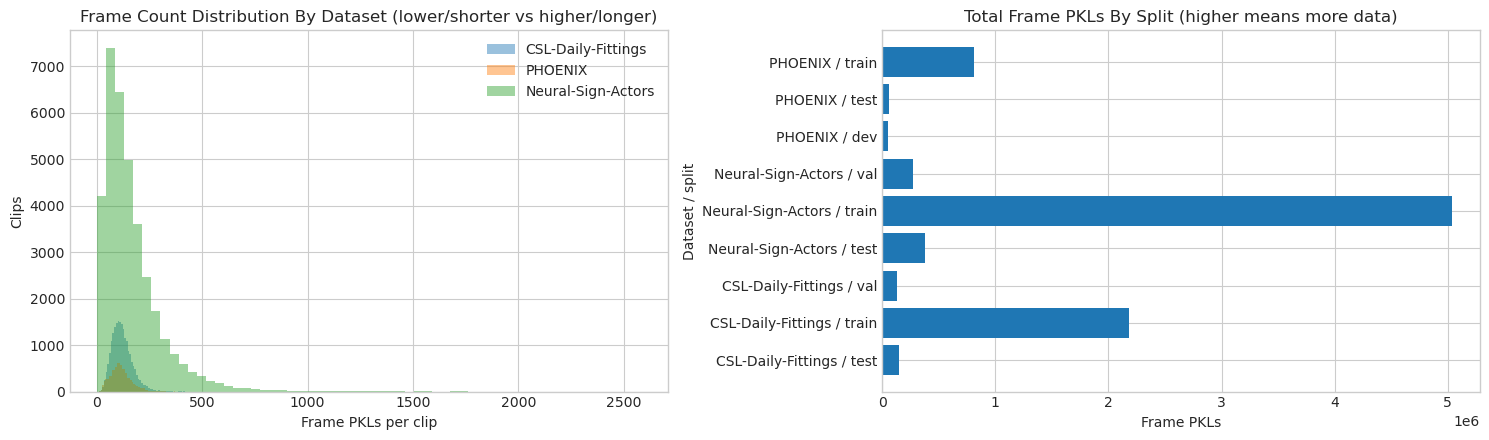

In [8]:

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

plot_df = combined_df[combined_df['frame_pkls'] > 0].copy()
for dataset in plot_df['dataset'].dropna().unique():
    vals = plot_df.loc[plot_df['dataset'] == dataset, 'frame_pkls'].values
    axes[0].hist(vals, bins=60, alpha=0.45, label=dataset)
axes[0].set_title('Frame Count Distribution By Dataset (lower/shorter vs higher/longer)')
axes[0].set_xlabel('Frame PKLs per clip')
axes[0].set_ylabel('Clips')
axes[0].legend()

bar_df = combined_stats.copy()
bar_df['label'] = bar_df['dataset'] + ' / ' + bar_df['split']
axes[1].barh(bar_df['label'], bar_df['frame_pkls_sum'])
axes[1].set_title('Total Frame PKLs By Split (higher means more data)')
axes[1].set_xlabel('Frame PKLs')
axes[1].set_ylabel('Dataset / split')

fig.tight_layout()
plot_path = PLOT_DIR / 'frame_count_stats.png'
fig.savefig(plot_path, dpi=150, bbox_inches='tight')
print('Wrote:', plot_path)
plt.show()


## Random Sample Records And Pose Schemas

In [9]:

sample_rows = []
schema_rows = []

for dataset, df in [('CSL-Daily-Fittings', csl_df), ('PHOENIX', phoenix_df), ('Neural-Sign-Actors', nsa_df)]:
    if len(df) == 0:
        continue
    n = min(SAMPLE_SIZE, len(df))
    sample_df = df.sample(n, random_state=RNG_SEED).copy().reset_index(drop=True)
    for _, row in sample_df.iterrows():
        pose_dir = Path(row['pose_dir'])
        frame_files = sorted(pose_dir.glob('*.pkl'))
        first_frame = frame_files[0] if frame_files else None
        sample_rows.append({
            'dataset': dataset,
            'split': row.get('split'),
            'clip_id': row.get('clip_id'),
            'frame_pkls': int(row.get('frame_pkls', 0)),
            'pose_dir': str(pose_dir),
            'first_frame_pkl': str(first_frame) if first_frame else '',
        })
        if first_frame is not None:
            try:
                schema = describe_frame_schema(first_frame)
                schema['dataset'] = dataset
                schema['split'] = row.get('split')
                schema['clip_id'] = row.get('clip_id')
                schema_rows.append(schema)
            except Exception as e:
                warnings.warn(f'Failed schema load for {first_frame}: {e}')

sample_df = pd.DataFrame(sample_rows)
schema_df = pd.DataFrame(schema_rows)

display(sample_df)
display(schema_df)

sample_csv = ARTIFACT_DIR / 'random_sample_records.csv'
schema_csv = ARTIFACT_DIR / 'sample_pose_schema.csv'
sample_df.to_csv(sample_csv, index=False)
schema_df.to_csv(schema_csv, index=False)
print('Wrote:', sample_csv)
print('Wrote:', schema_csv)


,dataset,split,clip_id,frame_pkls,pose_dir,first_frame_pkl
0,CSL-Daily-Fittings,train,S000885_P0004_T00,148,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...
1,CSL-Daily-Fittings,train,S003456_P0000_T00,122,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...
2,CSL-Daily-Fittings,train,S000121_P0008_T00,228,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...
3,CSL-Daily-Fittings,train,S005099_P0009_T00,37,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...
4,CSL-Daily-Fittings,train,S005468_P0006_T00,64,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...
5,CSL-Daily-Fittings,val,S003206_P0002_T00,80,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...
6,CSL-Daily-Fittings,train,S001262_P0008_T00,134,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...
7,CSL-Daily-Fittings,train,S001226_P0004_T00,117,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...
8,CSL-Daily-Fittings,train,S001312_P0000_T00,133,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...
9,CSL-Daily-Fittings,train,S001939_P0004_T00,183,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...


,path,type,keys,smplx_root_pose_shape,smplx_root_pose_dtype,smplx_body_pose_shape,smplx_body_pose_dtype,smplx_lhand_pose_shape,smplx_lhand_pose_dtype,smplx_rhand_pose_shape,...,split,clip_id,smplx_joint_proj_shape,smplx_joint_proj_dtype,lhand_bbox_shape,lhand_bbox_dtype,rhand_bbox_shape,rhand_bbox_dtype,face_bbox_shape,face_bbox_dtype
0,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,dict,"smplx_root_pose, smplx_body_pose, smplx_lhand_...","(3,)",float32,"(63,)",float32,"(45,)",float32,"(45,)",...,train,S000885_P0004_T00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,dict,"smplx_root_pose, smplx_body_pose, smplx_lhand_...","(3,)",float32,"(63,)",float32,"(45,)",float32,"(45,)",...,train,S003456_P0000_T00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,dict,"smplx_root_pose, smplx_body_pose, smplx_lhand_...","(3,)",float32,"(63,)",float32,"(45,)",float32,"(45,)",...,train,S000121_P0008_T00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,dict,"smplx_root_pose, smplx_body_pose, smplx_lhand_...","(3,)",float32,"(63,)",float32,"(45,)",float32,"(45,)",...,train,S005099_P0009_T00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,dict,"smplx_root_pose, smplx_body_pose, smplx_lhand_...","(3,)",float32,"(63,)",float32,"(45,)",float32,"(45,)",...,train,S005468_P0006_T00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,dict,"smplx_root_pose, smplx_body_pose, smplx_lhand_...","(3,)",float32,"(63,)",float32,"(45,)",float32,"(45,)",...,val,S003206_P0002_T00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,dict,"smplx_root_pose, smplx_body_pose, smplx_lhand_...","(3,)",float32,"(63,)",float32,"(45,)",float32,"(45,)",...,train,S001262_P0008_T00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,dict,"smplx_root_pose, smplx_body_pose, smplx_lhand_...","(3,)",float32,"(63,)",float32,"(45,)",float32,"(45,)",...,train,S001226_P0004_T00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,dict,"smplx_root_pose, smplx_body_pose, smplx_lhand_...","(3,)",float32,"(63,)",float32,"(45,)",float32,"(45,)",...,train,S001312_P0000_T00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...,dict,"smplx_root_pose, smplx_body_pose, smplx_lhand_...","(3,)",float32,"(63,)",float32,"(45,)",float32,"(45,)",...,train,S001939_P0004_T00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Wrote: /home/cem/tez/exp/new_data/01_csl_phoenix_neural_sign_actors_exploration_and_stats/random_sample_records.csv
Wrote: /home/cem/tez/exp/new_data/01_csl_phoenix_neural_sign_actors_exploration_and_stats/sample_pose_schema.csv


## CSL Text / Gloss Statistics

## NB39-Style Random Triptych Videos

This section renders 3 random clips per dataset using `smplx_gif_renderer_nb39_reference.py` and the same SOKE visual preset used by Notebook 39. The available SOKE_DATA folders do not contain paired RGB and reconstruction streams, so each triptych is three synchronized views of the same SMPL-X motion: front, side, and three-quarter.


In [11]:

from IPython.display import Video
import sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))


RUN_TRIPTYCH_RENDER = os.environ.get('NEW_DATA_RENDER_TRIPTYCHS', '1') == '1'
TRIPTYCH_FORCE = os.environ.get('NEW_DATA_RENDER_FORCE', '0') == '1'
TRIPTYCH_PER_DATASET = int(os.environ.get('NEW_DATA_TRIPTYCHS_PER_DATASET', '3'))
TRIPTYCH_MAX_RENDER_FRAMES = int(os.environ.get('NEW_DATA_RENDER_MAX_FRAMES', '96'))
TRIPTYCH_OUTPUT_FPS = float(os.environ.get('NEW_DATA_RENDER_OUTPUT_FPS', '24.0'))
TRIPTYCH_SEED = int(os.environ.get('NEW_DATA_TRIPTYCH_SEED', str(RNG_SEED)))
TRIPTYCH_DIR = ARTIFACT_DIR / 'triptych_videos_nb39_style'
TRIPTYCH_DIR.mkdir(parents=True, exist_ok=True)
TRIPTYCH_MANIFEST = TRIPTYCH_DIR / 'triptych_manifest.csv'


def frame_sort_key(path: Path):
    import re
    nums = re.findall(r'(\d+)', path.stem)
    return tuple(int(x) for x in nums[-2:]) if nums else (path.name,)


def stack_pose_frames_to_169(pose_dir: Path, max_source_frames: int | None = None) -> np.ndarray:
    frame_files = sorted(Path(pose_dir).glob('*.pkl'), key=frame_sort_key)
    if max_source_frames is not None and max_source_frames > 0 and len(frame_files) > max_source_frames:
        idx = np.linspace(0, len(frame_files) - 1, num=max_source_frames, dtype=np.int64)
        frame_files = [frame_files[int(i)] for i in idx]
    rows = []
    for fp in frame_files:
        obj = load_pickle_or_torch(fp)
        if not isinstance(obj, dict):
            continue
        pose156 = np.concatenate([
            np.asarray(obj['smplx_root_pose'], dtype=np.float32).reshape(-1),
            np.asarray(obj['smplx_body_pose'], dtype=np.float32).reshape(-1),
            np.asarray(obj['smplx_lhand_pose'], dtype=np.float32).reshape(-1),
            np.asarray(obj['smplx_rhand_pose'], dtype=np.float32).reshape(-1),
        ])
        betas10 = np.asarray(obj['smplx_shape'], dtype=np.float32).reshape(-1)[:10]
        transl3 = np.asarray(obj['cam_trans'], dtype=np.float32).reshape(-1)[:3]
        rows.append(np.concatenate([pose156, betas10, transl3]).astype(np.float32))
    if not rows:
        raise RuntimeError(f'No frame PKLs could be loaded from {pose_dir}')
    motion = np.stack(rows, axis=0).astype(np.float32)
    if motion.shape[1] != 169:
        raise ValueError(f'Expected stacked motion shape [T,169], got {motion.shape}')
    return np.nan_to_num(motion, nan=0.0, posinf=0.0, neginf=0.0)


def select_triptych_rows() -> pd.DataFrame:
    rows = []
    eligible = combined_df[(combined_df['pose_exists']) & (combined_df['frame_pkls'] > 1)].copy()
    for dataset, df in eligible.groupby('dataset'):
        n = min(TRIPTYCH_PER_DATASET, len(df))
        pick = df.sample(n=n, random_state=TRIPTYCH_SEED + abs(hash(dataset)) % 10000)
        rows.append(pick.sort_values(['split', 'clip_id']))
    if not rows:
        return pd.DataFrame(columns=eligible.columns)
    return pd.concat(rows, ignore_index=True)


def safe_file_stem(value: str) -> str:
    import re
    out = re.sub(r'[^A-Za-z0-9_.-]+', '_', str(value)).strip('_')
    return out[:140] or 'sample'


def render_one_triptych(renderer, row, sample_index: int) -> dict:
    dataset = str(row['dataset'])
    split = str(row['split'])
    clip_id = str(row['clip_id'])
    pose_dir = Path(row['pose_dir'])
    stem = f"{sample_index:02d}_{safe_file_stem(dataset)}__{safe_file_stem(split)}__{safe_file_stem(clip_id)}"
    dataset_dir = TRIPTYCH_DIR / safe_file_stem(dataset)
    dataset_dir.mkdir(parents=True, exist_ok=True)
    front_mp4 = dataset_dir / f'{stem}__front_nb39.mp4'
    side_mp4 = dataset_dir / f'{stem}__side_nb39.mp4'
    threeq_mp4 = dataset_dir / f'{stem}__threequarter_nb39.mp4'
    panel_mp4 = dataset_dir / f'{stem}__triptych_nb39_style.mp4'

    rec = {
        'sample_index': sample_index,
        'dataset': dataset,
        'split': split,
        'clip_id': clip_id,
        'frame_pkls': int(row['frame_pkls']),
        'pose_dir': str(pose_dir),
        'front_mp4': str(front_mp4),
        'side_mp4': str(side_mp4),
        'threequarter_mp4': str(threeq_mp4),
        'panel_mp4': str(panel_mp4),
        'status': 'not_started',
    }
    if panel_mp4.exists() and not TRIPTYCH_FORCE:
        rec['status'] = 'ok'
        rec['skipped_existing'] = True
        return rec

    motion169 = stack_pose_frames_to_169(pose_dir)
    source_duration_sec = float(len(motion169) / TRIPTYCH_OUTPUT_FPS)
    render_kwargs = dict(
        show_skeleton=False,
        source_duration_sec=source_duration_sec,
        max_render_frames=TRIPTYCH_MAX_RENDER_FRAMES,
        face_step=1,
    )

    renderer.camera_elev = 6.0
    renderer.camera_zoom = 0.49
    renderer.camera_azim = -90.0
    front_res = renderer.render_smplx_mp4(motion169, front_mp4, **render_kwargs)
    renderer.camera_azim = 0.0
    side_res = renderer.render_smplx_mp4(motion169, side_mp4, **render_kwargs)
    renderer.camera_azim = -45.0
    threeq_res = renderer.render_smplx_mp4(motion169, threeq_mp4, **render_kwargs)

    subtitle = f'{dataset} | split={split} | clip={clip_id} | source frames={len(motion169)} | rendered frames={front_res.rendered_frames}'
    renderer.compose_panel_mp4(
        panel_video_paths=[front_mp4, side_mp4, threeq_mp4],
        out_mp4_path=panel_mp4,
        panel_size=(720, 720),
        labels=['SMPL-X Front', 'SMPL-X Side', 'SMPL-X 3/4'],
        subtitle_text=subtitle,
        subtitle_height=116,
        subtitle_fontsize=22,
        draw_panel_dividers=False,
        keep_audio_from_first=False,
        output_fps=front_res.output_fps,
        title_band_height=72,
        title_fontsize=28,
        title_alignment='center',
    )
    rec.update({
        'status': 'ok',
        'skipped_existing': False,
        'source_frames': int(len(motion169)),
        'rendered_frames': int(front_res.rendered_frames),
        'output_fps': float(front_res.output_fps),
        'output_duration_sec': float(front_res.output_duration_sec),
    })
    return rec


triptych_selection_df = select_triptych_rows()
triptych_selection_csv = TRIPTYCH_DIR / 'selected_random_triptych_clips.csv'
triptych_selection_df.to_csv(triptych_selection_csv, index=False)
display(Markdown(f'### Random Triptych Selection\n`{triptych_selection_csv}`'))
display(triptych_selection_df[['dataset', 'split', 'clip_id', 'frame_pkls', 'pose_dir']])

triptych_rows = []
if RUN_TRIPTYCH_RENDER:
    if not TORCH_AVAILABLE:
        raise RuntimeError('Torch is required for NB39-style SMPL-X rendering.')
    from smplx_gif_renderer_nb39_reference import SMPLXGifRenderer

    renderer = SMPLXGifRenderer(
        model_root=ROOT / 'body_models',
        require_gpu=torch.cuda.is_available(),
        output_size=(720, 720),
        camera_elev=6.0,
        camera_azim=-90.0,
        camera_zoom=0.49,
        default_max_render_frames=TRIPTYCH_MAX_RENDER_FRAMES,
        face_step=1,
        style_preset='soke',
    )
    print('NB39 renderer device:', renderer.get_device_name())
    print('Triptych render dir:', TRIPTYCH_DIR)
    try:
        for i, row in enumerate(triptych_selection_df.to_dict('records'), start=1):
            print(f"render {i}/{len(triptych_selection_df)}: {row['dataset']} {row['split']} {row['clip_id']}")
            try:
                triptych_rows.append(render_one_triptych(renderer, row, i))
            except Exception as exc:
                rec = dict(row)
                rec.update({'sample_index': i, 'status': 'error', 'error_type': type(exc).__name__, 'error_repr': repr(exc)})
                triptych_rows.append(rec)
            pd.DataFrame(triptych_rows).to_csv(TRIPTYCH_MANIFEST, index=False)
    finally:
        del renderer
        if TORCH_AVAILABLE and torch.cuda.is_available():
            torch.cuda.empty_cache()
else:
    print('Triptych rendering disabled. Set NEW_DATA_RENDER_TRIPTYCHS=1 to render.')
    if TRIPTYCH_MANIFEST.exists():
        triptych_rows = pd.read_csv(TRIPTYCH_MANIFEST).to_dict('records')

triptych_manifest_df = pd.DataFrame(triptych_rows)
triptych_manifest_df.to_csv(TRIPTYCH_MANIFEST, index=False)
display(Markdown(f'### NB39-Style Triptych Render Manifest\n`{TRIPTYCH_MANIFEST}`'))
display(triptych_manifest_df)

ok_triptychs = triptych_manifest_df[triptych_manifest_df.get('status', '') == 'ok'] if len(triptych_manifest_df) else pd.DataFrame()
for row in ok_triptychs.itertuples(index=False):
    display(Markdown(f"#### {row.dataset} / {row.split} / {row.clip_id}"))
    display(Video(filename=row.panel_mp4, embed=False, html_attributes='controls'))


### Random Triptych Selection
`/home/cem/tez/exp/new_data/01_csl_phoenix_neural_sign_actors_exploration_and_stats/triptych_videos_nb39_style/selected_random_triptych_clips.csv`

,dataset,split,clip_id,frame_pkls,pose_dir
0,CSL-Daily-Fittings,train,S001032_P0000_T00,128,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...
1,CSL-Daily-Fittings,train,S004683_P0003_T00,99,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...
2,CSL-Daily-Fittings,train,S006643_P0009_T00,83,/home/cem/tez/exp/DATA/SOKE_DATA/CSL-Daily-Fit...
3,Neural-Sign-Actors,train,20qFsdFD3io_24-8-rgb_front,75,/home/cem/tez/exp/DATA/SOKE_DATA/Neural-Sign-A...
4,Neural-Sign-Actors,train,5Uy3r6Sl4pM_1-8-rgb_front,44,/home/cem/tez/exp/DATA/SOKE_DATA/Neural-Sign-A...
5,Neural-Sign-Actors,train,CVpmdnJpOdE_3-5-rgb_front,441,/home/cem/tez/exp/DATA/SOKE_DATA/Neural-Sign-A...
6,PHOENIX,test,17February_2010_Wednesday_heute-1482,134,/home/cem/tez/exp/DATA/SOKE_DATA/phoenix_poses...
7,PHOENIX,train,09August_2009_Sunday_tagesschau-1185,78,/home/cem/tez/exp/DATA/SOKE_DATA/phoenix_poses...
8,PHOENIX,train,16May_2010_Sunday_tagesschau-5228,204,/home/cem/tez/exp/DATA/SOKE_DATA/phoenix_poses...


NB39 renderer device: NVIDIA GeForce RTX 4090
Triptych render dir: /home/cem/tez/exp/new_data/01_csl_phoenix_neural_sign_actors_exploration_and_stats/triptych_videos_nb39_style
render 1/9: CSL-Daily-Fittings train S001032_P0000_T00


ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

render 2/9: CSL-Daily-Fittings train S004683_P0003_T00


...

#### Neural-Sign-Actors / train / 5Uy3r6Sl4pM_1-8-rgb_front

#### Neural-Sign-Actors / train / CVpmdnJpOdE_3-5-rgb_front

#### PHOENIX / test / 17February_2010_Wednesday_heute-1482

#### PHOENIX / train / 09August_2009_Sunday_tagesschau-1185

#### PHOENIX / train / 16May_2010_Sunday_tagesschau-5228

## Reproduction Notes

Useful environment flags:

- `NEW_DATA_MAX_CLIPS_PER_SPLIT=100` limits each split scan for fast smoke execution.
- `NEW_DATA_SAMPLE_SIZE=10` controls random sample rows per dataset.
- `NEW_DATA_RENDER_TRIPTYCHS=1` renders NB39-style triptych videos. This defaults to enabled.
- `NEW_DATA_TRIPTYCHS_PER_DATASET=3` controls triptych count per dataset.
- `NEW_DATA_RENDER_MAX_FRAMES=96` controls max rendered frames per view while preserving source duration.
- `NEW_DATA_RENDER_FORCE=1` regenerates existing triptych MP4s.

Main artifacts are written to `new_data/01_csl_phoenix_neural_sign_actors_exploration_and_stats/`.
